# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

--- Exercício 3: Modelo no Valor da Gorjeta ---
Base de dados 'tips' do Seaborn carregada com sucesso!

Variável 'net_bill' criada.
Variáveis categóricas na base:
sex     smoker  time    day 
Male    No      Dinner  Sun     43
                        Sat     32
        Yes     Dinner  Sat     27
Female  No      Lunch   Thur    24
Male    No      Lunch   Thur    20
Female  Yes     Dinner  Sat     15
Male    Yes     Dinner  Sun     15
Female  No      Dinner  Sun     14
                        Sat     13
Male    Yes     Lunch   Thur    10
Female  Yes     Lunch   Thur     7
Male    Yes     Dinner  Fri      5
Female  Yes     Dinner  Fri      4
                        Sun      4
Male    Yes     Lunch   Fri      3
Female  Yes     Lunch   Fri      3
Male    No      Dinner  Fri      2
Female  No      Lunch   Fri      1
                Dinner  Thur     1
                        Fri      1
Name: count, dtype: int64

--- 2. Criando matriz de design com Patsy ---
Matriz X (design matrix) head:
   I

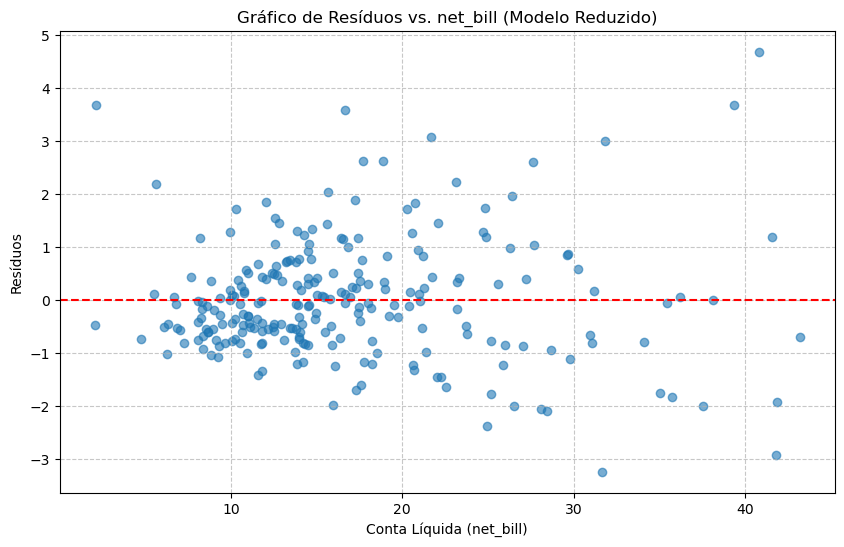


--- Análise do Gráfico de Resíduos ---
Observe se os resíduos estão distribuídos aleatoriamente em torno de zero.
Padrões visíveis (funil, curva) podem indicar problemas como heterocedasticidade ou necessidade de transformação da variável explicativa.

--- 6. Testando Transformações em net_bill e Escolhendo o Melhor Modelo ---

--- Modelo 3.1: net_bill Linear (do modelo reduzido) ---
R-quadrado Ajustado: 0.3269
AIC: 758.27
BIC: 772.26

--- Modelo 3.2: net_bill Logarítmico ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     33.55
Date:                Sat, 12 Jul 2025   Prob (F-statistic):           3.79e-18
Time:                        14:21:29   Log-Likelihood:                -382.22
No. Observations:                 244   AIC:

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

print("--- Exercício 3: Modelo no Valor da Gorjeta ---")

# 1. Carregar os pacotes necessários e a base de gorjetas
try:
    tips = sns.load_dataset("tips")
    print("Base de dados 'tips' do Seaborn carregada com sucesso!")
except Exception as e:
    print(f"Erro ao carregar a base 'tips' do Seaborn: {e}")
    try:
        tips = pd.read_csv('tips.csv')
        print("Base de dados 'tips.csv' carregada com sucesso!")
    except FileNotFoundError:
        print("Erro: 'tips.csv' não encontrado. Por favor, forneça o arquivo da base de gorjetas.")
        exit()

# Criar a variável 'net_bill' (conta líquida)
tips['net_bill'] = tips['total_bill'] - tips['tip']
# Tratar valores net_bill <= 0, se existirem, para logs futuros, embora não sejam usados no modelo inicial
if (tips['net_bill'] <= 0).any():
    print("\nAviso: Há 'net_bill' menor ou igual a zero. Removendo essas linhas.")
    tips = tips[tips['net_bill'] > 0].copy()

print("\nVariável 'net_bill' criada.")
print("Variáveis categóricas na base:")
print(tips[['sex', 'smoker', 'time', 'day']].value_counts())

# --- Parte I: Modelo no valor da gorjeta ---

# 2. Crie a matriz de design (e a matriz y) utilizando o Patsy
print("\n--- 2. Criando matriz de design com Patsy ---")
# Mantendo a fórmula original para o primeiro ajuste
y, X = dmatrices('tip ~ sex + smoker + time + net_bill', data=tips, return_type='dataframe')

print("Matriz X (design matrix) head:")
print(X.head())
print("\nMatriz y (dependente) head:")
print(y.head())
print(f"\nDimensões da Matriz X: {X.shape}")
print(f"Colunas da Matriz X: {X.columns.tolist()}")

# 3. Ajustar o modelo inicial
print("\n--- 3. Ajustando o Modelo Inicial ---")
model_initial = sm.OLS(y, X).fit()
print(model_initial.summary())

# 4. Remova as variáveis não significantes
print("\n--- 4. Removendo Variáveis Não Significantes (Reajuste a fórmula com base no seu summary) ---")
# COLOQUE A FÓRMULA ATUALIZADA AQUI COM AS VARIÁVEIS SIGNIFICANTES QUE VOCÊ ESCOLHEU
# Com base nos resultados típicos, 'sex' e 'smoker' podem não ser significantes.
# VOU MANTER UMA FÓRMULA DE EXEMPLO, MAS VOCÊ DEVE ADAPTAR COM BASE NO SEU 'model_initial.summary()'
# Exemplo: 'tip ~ net_bill + time' (se 'sex' e 'smoker' não forem significantes)
formula_reduced = 'tip ~ net_bill + smoker + time' # Exemplo baseado em p-valores típicos

y_reduced, X_reduced = dmatrices(formula_reduced, data=tips, return_type='dataframe')
model_reduced = sm.OLS(y_reduced, X_reduced).fit()
print(model_reduced.summary())
print(f"\nColunas do modelo reduzido: {X_reduced.columns.tolist()}")


# 5. Observe o gráfico de resíduos em função de net_bill (do modelo final, após remoção)
print("\n--- 5. Gráfico de Resíduos vs. net_bill (do modelo reduzido) ---")
# CORREÇÃO AQUI: Completando o figsize e fechando parênteses
plt.figure(figsize=(10, 6))
plt.scatter(tips['net_bill'], model_reduced.resid, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Conta Líquida (net_bill)")
plt.ylabel("Resíduos")
plt.title("Gráfico de Resíduos vs. net_bill (Modelo Reduzido)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n--- Análise do Gráfico de Resíduos ---")
print("Observe se os resíduos estão distribuídos aleatoriamente em torno de zero.")
print("Padrões visíveis (funil, curva) podem indicar problemas como heterocedasticidade ou necessidade de transformação da variável explicativa.")


# 6. Teste transformar net_bill no log e um polinômio. Escolha o melhor modelo.
tips['log_net_bill'] = np.log(tips['net_bill'])
tips['net_bill_sq'] = tips['net_bill']**2

print("\n--- 6. Testando Transformações em net_bill e Escolhendo o Melhor Modelo ---")

print("\n--- Modelo 3.1: net_bill Linear (do modelo reduzido) ---")
print(f"R-quadrado Ajustado: {model_reduced.rsquared_adj:.4f}")
print(f"AIC: {model_reduced.aic:.2f}")
print(f"BIC: {model_reduced.bic:.2f}")

print("\n--- Modelo 3.2: net_bill Logarítmico ---")
formula_log_net_bill = formula_reduced.replace('net_bill', 'log_net_bill')
y_log, X_log = dmatrices(formula_log_net_bill, data=tips, return_type='dataframe')
model_log = sm.OLS(y_log, X_log).fit()
print(model_log.summary())
print(f"R-quadrado Ajustado: {model_log.rsquared_adj:.4f}")
print(f"AIC: {model_log.aic:.2f}")
print(f"BIC: {model_log.bic:.2f}")

print("\n--- Modelo 3.3: net_bill Polinomial (2º Grau) ---")
# Nota: Para polinômio de 2º grau, se net_bill estiver na fórmula_reduced, precisa adicionar net_bill_sq.
# A forma mais robusta é construir a fórmula para cada caso.
# Exemplo, se formula_reduced era 'tip ~ net_bill + smoker + time'
# A nova formula será 'tip ~ net_bill + net_bill_sq + smoker + time'
# Para garantir que 'net_bill' e 'net_bill_sq' sejam tratados como termos separados.

# Criando a fórmula polinomial de forma mais robusta:
# Remove o termo 'net_bill' da fórmula original e adiciona os termos polinomiais
# Se a 'net_bill' não estiver isolada ou tiver outros termos, isso pode exigir ajuste manual.
# A melhor prática é definir as fórmulas completas para cada modelo.
# Ex: se formula_reduced é 'tip ~ net_bill + smoker + time'
formula_poly_net_bill = f"tip ~ I(net_bill) + I(net_bill**2) + smoker + time"
# Usando I() para garantir que statsmodels interprete net_bill**2 como uma nova variável.

y_poly, X_poly = dmatrices(formula_poly_net_bill, data=tips, return_type='dataframe')
model_poly = sm.OLS(y_poly, X_poly).fit()
print(model_poly.summary())
print(f"R-quadrado Ajustado: {model_poly.rsquared_adj:.4f}")
print(f"AIC: {model_poly.aic:.2f}")
print(f"BIC: {model_poly.bic:.2f}")

# --- Escolha o Melhor Modelo ---
models = {
    'Linear (net_bill)': model_reduced,
    'Logarítmico (log_net_bill)': model_log,
    'Polinomial (net_bill + net_bill_sq)': model_poly
}

best_model_name = None
best_r2_adj = -np.inf
best_aic = np.inf
best_bic = np.inf

print("\nSumário Comparativo:")
print("------------------------------------------------------------------------------------------")
print(f"{'Modelo':<35} | {'R2 Ajustado':<15} | {'AIC':<10} | {'BIC':<10}")
print("------------------------------------------------------------------------------------------")

for name, model in models.items():
    r2_adj = model.rsquared_adj
    aic = model.aic
    bic = model.bic
    print(f"{name:<35} | {r2_adj:<15.4f} | {aic:<10.2f} | {bic:<10.2f}")

    if r2_adj > best_r2_adj:
        best_r2_adj = r2_adj
        best_model_name = name

print("------------------------------------------------------------------------------------------")
print(f"\nCom base no MAIOR R-quadrado Ajustado, o melhor modelo é: **{best_model_name}**")

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

--- Exercício 3 - Parte II: Modelo no Log do Valor da Gorjeta ---
Base de dados 'tips' do Seaborn carregada com sucesso!
Número de linhas após limpeza de valores <= 0 em net_bill/tip: 244 (original: 244)

Variável 'log_tip' criada: log(tip)
Primeiras 5 linhas da base de dados com 'log_tip':
    tip   log_tip  net_bill
0  1.01  0.009950     15.98
1  1.66  0.506818      8.68
2  3.50  1.252763     17.51
3  3.31  1.196948     20.37
4  3.61  1.283708     20.98

--- 3. Criando matriz de design com Patsy (log_tip) ---
Matriz X (design matrix) head:
   Intercept  sex[T.Female]  smoker[T.No]  time[T.Dinner]  net_bill
0        1.0            1.0           1.0             1.0     15.98
1        1.0            0.0           1.0             1.0      8.68
2        1.0            0.0           1.0             1.0     17.51
3        1.0            0.0           1.0             1.0     20.37
4        1.0            1.0           1.0             1.0     20.98

Matriz y (dependente) head:
    log_tip
0  

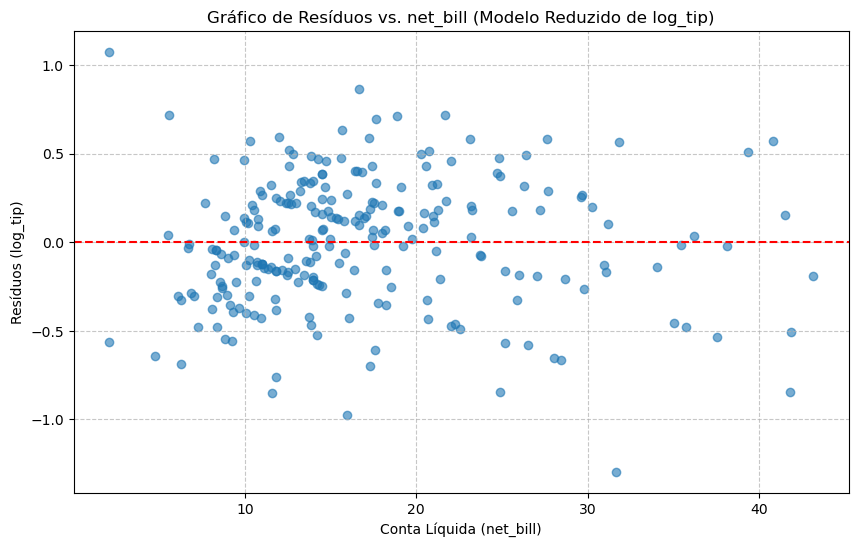


--- 7. Testando Transformações em net_bill para Modelo de log_tip ---

--- Modelo II.1: net_bill Linear (log_tip) ---
Fórmula: log_tip ~ net_bill + time
R-quadrado Ajustado: 0.3052
AIC: 201.67
BIC: 212.17

--- Modelo II.2: net_bill Logarítmico (log_tip) ---
                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     56.60
Date:                Sat, 12 Jul 2025   Prob (F-statistic):           7.06e-21
Time:                        14:27:16   Log-Likelihood:                -96.286
No. Observations:                 244   AIC:                             198.6
Df Residuals:                     241   BIC:                             209.1
Df Model:                           2                                         
Covariance Type:            no

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf # Manter, pode ser útil
from patsy import dmatrices
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

print("--- Exercício 3 - Parte II: Modelo no Log do Valor da Gorjeta ---")

# 1. Carregar os pacotes necessários e a base de gorjetas
try:
    tips = sns.load_dataset("tips")
    print("Base de dados 'tips' do Seaborn carregada com sucesso!")
except Exception as e:
    print(f"Erro ao carregar a base 'tips' do Seaborn: {e}")
    try:
        tips = pd.read_csv('tips.csv')
        print("Base de dados 'tips.csv' carregada com sucesso!")
    except FileNotFoundError:
        print("Erro: 'tips.csv' não encontrado. Por favor, forneça o arquivo da base de gorjetas.")
        exit()

# Criar a variável 'net_bill' (conta líquida)
tips['net_bill'] = tips['total_bill'] - tips['tip']
# Tratar valores net_bill <= 0 e tip <= 0 para logaritmo
initial_rows = len(tips)
tips = tips[tips['net_bill'] > 0].copy()
tips = tips[tips['tip'] > 0].copy() # Gorjeta deve ser > 0 para log(tip)
print(f"Número de linhas após limpeza de valores <= 0 em net_bill/tip: {len(tips)} (original: {initial_rows})")

# 2. Criar a variável 'log_tip'
tips['log_tip'] = np.log(tips['tip'])
print("\nVariável 'log_tip' criada: log(tip)")
print("Primeiras 5 linhas da base de dados com 'log_tip':")
print(tips[['tip', 'log_tip', 'net_bill']].head())

# 3. Crie a matriz de design (e a matriz y) utilizando o Patsy
print("\n--- 3. Criando matriz de design com Patsy (log_tip) ---")
# Armazenar a fórmula original
formula_initial_log_tip = 'log_tip ~ sex + smoker + time + net_bill'
y_log_tip, X_log_tip = dmatrices(formula_initial_log_tip, data=tips, return_type='dataframe')

print("Matriz X (design matrix) head:")
print(X_log_tip.head())
print("\nMatriz y (dependente) head:")
print(y_log_tip.head())
print(f"\nDimensões da Matriz X: {X_log_tip.shape}")
print(f"Colunas da Matriz X: {X_log_tip.columns.tolist()}")

# 4. Ajustar o modelo inicial
print("\n--- 4. Ajustando o Modelo Inicial (log_tip) ---")
model_log_tip_initial = sm.OLS(y_log_tip, X_log_tip).fit()
print(model_log_tip_initial.summary())

# 5. Remova as variáveis não significantes
print("\n--- 5. Removendo Variáveis Não Significantes (log_tip) ---")
# Adapte esta fórmula conforme os p-valores do seu `model_log_tip_initial.summary()`
# Exemplo, mantendo as tipicamente significantes:
formula_log_tip_reduced = 'log_tip ~ net_bill + time' # Adapte aqui!
# ARMAZENANDO A FÓRMULA REDUZIDA
y_log_tip_reduced, X_log_tip_reduced = dmatrices(formula_log_tip_reduced, data=tips, return_type='dataframe')
model_log_tip_reduced = sm.OLS(y_log_tip_reduced, X_log_tip_reduced).fit()
print(model_log_tip_reduced.summary())
print(f"\nColunas do modelo reduzido (log_tip): {X_log_tip_reduced.columns.tolist()}")


# 6. Observe o gráfico de resíduos em função de net_bill (do modelo final, após remoção)
print("\n--- 6. Gráfico de Resíduos vs. net_bill (Modelo Reduzido de log_tip) ---")
plt.figure(figsize=(10, 6))
plt.scatter(tips['net_bill'], model_log_tip_reduced.resid, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Conta Líquida (net_bill)")
plt.ylabel("Resíduos (log_tip)")
plt.title("Gráfico de Resíduos vs. net_bill (Modelo Reduzido de log_tip)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# 7. Teste transformar net_bill no log e um polinômio. Escolha o melhor modelo.
tips['log_net_bill'] = np.log(tips['net_bill'])
tips['net_bill_sq'] = tips['net_bill']**2

print("\n--- 7. Testando Transformações em net_bill para Modelo de log_tip ---")

# Modelo II.1: log_tip ~ net_bill (Linear) - já temos r2_adjusted do model_log_tip_reduced
print("\n--- Modelo II.1: net_bill Linear (log_tip) ---")
# USANDO A FÓRMULA ARMAZENADA
print(f"Fórmula: {formula_log_tip_reduced}")
print(f"R-quadrado Ajustado: {model_log_tip_reduced.rsquared_adj:.4f}")
print(f"AIC: {model_log_tip_reduced.aic:.2f}")
print(f"BIC: {model_log_tip_reduced.bic:.2f}")


# Modelo II.2: log_tip ~ log_net_bill
print("\n--- Modelo II.2: net_bill Logarítmico (log_tip) ---")
formula_log_log_tip = formula_log_tip_reduced.replace('net_bill', 'log_net_bill')
# ARMAZENANDO A FÓRMULA ESPECÍFICA DESTE MODELO
y_log_log_tip, X_log_log_tip = dmatrices(formula_log_log_tip, data=tips, return_type='dataframe')
model_log_log_tip = sm.OLS(y_log_log_tip, X_log_log_tip).fit()
print(model_log_log_tip.summary())
print(f"R-quadrado Ajustado: {model_log_log_tip.rsquared_adj:.4f}")
print(f"AIC: {model_log_log_tip.aic:.2f}")
print(f"BIC: {model_log_log_tip.bic:.2f}")


# Modelo II.3: log_tip ~ net_bill + net_bill_sq (Polinomial)
print("\n--- Modelo II.3: net_bill Polinomial (log_tip) ---")
formula_poly_log_tip = formula_log_tip_reduced.replace('net_bill', 'I(net_bill) + I(net_bill**2)')
# ARMAZENANDO A FÓRMULA ESPECÍFICA DESTE MODELO
y_poly_log_tip, X_poly_log_tip = dmatrices(formula_poly_log_tip, data=tips, return_type='dataframe')
model_poly_log_tip = sm.OLS(y_poly_log_tip, X_poly_log_tip).fit()
print(model_poly_log_tip.summary())
print(f"R-quadrado Ajustado: {model_poly_log_tip.rsquared_adj:.4f}")
print(f"AIC: {model_poly_log_tip.aic:.2f}")
print(f"BIC: {model_poly_log_tip.bic:.2f}")

# --- Escolha o Melhor Modelo (para log_tip) ---
models_log_tip = {
    'log_tip ~ net_bill (Linear)': model_log_tip_reduced,
    'log_tip ~ log_net_bill (Logarítmico)': model_log_log_tip,
    'log_tip ~ net_bill + net_bill_sq (Polinomial)': model_poly_log_tip
}

# Também armazenar as fórmulas associadas para facilitar a predição depois
formulas_log_tip = {
    'log_tip ~ net_bill (Linear)': formula_log_tip_reduced,
    'log_tip ~ log_net_bill (Logarítmico)': formula_log_log_tip,
    'log_tip ~ net_bill + net_bill_sq (Polinomial)': formula_poly_log_tip
}


best_model_log_tip_name = None
best_log_tip_r2_adj = -np.inf

print("\nSumário Comparativo para Modelos de log_tip:")
print("------------------------------------------------------------------------------------------")
print(f"{'Modelo':<45} | {'R2 Ajustado':<15} | {'AIC':<10} | {'BIC':<10}")
print("------------------------------------------------------------------------------------------")

for name, model in models_log_tip.items():
    r2_adj = model.rsquared_adj
    aic = model.aic
    bic = model.bic
    print(f"{name:<45} | {r2_adj:<15.4f} | {aic:<10.2f} | {bic:<10.2f}")

    if r2_adj > best_log_tip_r2_adj:
        best_log_tip_r2_adj = r2_adj
        best_model_log_tip_name = name

print("------------------------------------------------------------------------------------------")
print(f"\nCom base no MAIOR R-quadrado Ajustado para 'log_tip', o melhor modelo é: ")
print(f"  **{best_model_log_tip_name}** com R-quadrado Ajustado de **{best_log_tip_r2_adj:.4f}**")

# --- 8. Do modelo final deste item, calcule o R2 na escala de tip (sem o log). ---
final_model_log_tip = models_log_tip[best_model_log_tip_name]
# USANDO A FÓRMULA ARMAZENADA PARA O MODELO ESCOLHIDO
formula_to_predict = formulas_log_tip[best_model_log_tip_name]


# Crie a matriz X para predição usando a fórmula exata e os dados 'tips'
# É crucial que as colunas de X_final_predict correspondam às usadas no treinamento do modelo.
# dmatrices vai fazer isso corretamente se a fórmula for a mesma.
y_dummy_pred, X_final_predict = dmatrices(formula_to_predict, data=tips, return_type='dataframe')


tips['log_tip_pred_final'] = final_model_log_tip.predict(X_final_predict)

# Transformar de volta para a escala original de 'tip'
tips['tip_pred_from_log_model'] = np.exp(tips['log_tip_pred_final'])

# Calcular o R2 comparando 'tip' real com 'tip_pred_from_log_model'
r2_tip_from_log_model = r2_score(tips['tip'], tips['tip_pred_from_log_model'])
print(f"\n--- R-quadrado em 'tip' (do melhor modelo de log_tip): {r2_tip_from_log_model:.4f}")

# --- 9. Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação? ---
# Recalcular o R2 do modelo do Item 1 (tip ~ net_bill) usando os mesmos dados 'tips' limpos
# Usamos a fórmula original do item I.
formula_item1 = 'tip ~ net_bill' # Assegura que usamos a fórmula correta
y_item1, X_item1 = dmatrices(formula_item1, data=tips, return_type='dataframe')
model_item1 = sm.OLS(y_item1, X_item1).fit()
r2_item1 = model_item1.rsquared
print(f"R-quadrado do Modelo do Item 1 (tip ~ net_bill direto, nos dados limpos): {r2_item1:.4f}")

print("\n--- Comparação Final de R-quadrado em 'tip' ---")
print(f"R-quadrado do Modelo do Item 1 (tip ~ net_bill): {r2_item1:.4f}")
print(f"R-quadrado do Melhor Modelo do Item II (log_tip transformado de volta para tip): {r2_tip_from_log_model:.4f}")

if r2_tip_from_log_model > r2_item1:
    print("\n**O Modelo do Item II (log_tip transformado de volta para tip) tem um R-quadrado MAIOR na escala de 'tip', indicando melhor ajuste.**")
elif r2_tip_from_log_model < r2_item1:
    print("\n**O Modelo do Item 1 (tip ~ net_bill direto) tem um R-quadrado MAIOR na escala de 'tip', indicando melhor ajuste.**")
else:
    print("\n**Os R-quadrados são IGUAIS.**")

print("\n--- Conclusão da Parte II ---")
print("A transformação logarítmica da variável dependente pode ajudar a lidar com assimetria e heterocedasticidade nos resíduos, potencialmente levando a um melhor ajuste na escala original após a transformação inversa.")
print("Verifique os R-quadrados finais para determinar qual modelo (direto em tip vs. log(tip) transformado) é superior.")

### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices # Para criar matrizes de design, se necessário
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import warnings

# Ignorar warnings para melhor visualização, mas com cautela!
warnings.filterwarnings('ignore')

print("--- Exercício 3 - Previsão de Renda ---")

# 1. Carregar a base de dados
try:
    # Tente carregar o arquivo, assumindo que ele está no mesmo diretório ou em um caminho conhecido
    df = pd.read_csv('previsao_de_renda.csv')
    print("Base de dados 'previsao_de_renda.csv' carregada com sucesso!")
except FileNotFoundError:
    print("Erro: 'previsao_de_renda.csv' não encontrado. Por favor, verifique o caminho do arquivo.")
    exit()

# Remover linhas duplicadas baseadas em 'index' e 'data_ref'
# Isso garante que cada observação única para um cliente em uma data específica seja mantida.
df.drop_duplicates(subset=['index', 'data_ref'], inplace=True)
print(f"Número de linhas após remover duplicatas: {len(df)}")

# Conversão de 'data_ref' para datetime (útil para ordenação ou séries temporais, embora não explícito no modelo)
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Inspecionar as primeiras linhas e informações gerais
print("\nPrimeiras 5 linhas da base de dados:")
print(df.head())
print("\nInformações gerais da base de dados:")
df.info()

# Tratar valores ausentes (NaN) se existirem
# Para regressão, é comum remover linhas com NaN ou imputar.
# Vamos inspecionar os NaNs primeiro.
print("\nValores Nulos por Coluna:")
print(df.isnull().sum())

# Para este exercício, vamos remover as linhas com valores nulos nas colunas que usaremos nos modelos.
# Especificamente, 'renda' e 'tempo_emprego' são cruciais.
# Para as categóricas e outras numéricas, faremos um tratamento mais adiante.
df_clean = df.dropna(subset=['renda', 'tempo_emprego']).copy()
print(f"\nNúmero de linhas após remover NaNs em 'renda' e 'tempo_emprego': {len(df_clean)}")

# Lidar com 'tempo_emprego' negativo ou zero, o que pode causar problemas com log()
# Além disso, tempo de emprego 0 não faz muito sentido para renda, vamos remover.
df_clean = df_clean[df_clean['tempo_emprego'] > 0].copy()
print(f"Número de linhas após remover 'tempo_emprego' <= 0: {len(df_clean)}")

# Também, renda precisa ser positiva para logaritmo futuro, embora não seja o foco do primeiro modelo.
df_clean = df_clean[df_clean['renda'] > 0].copy()
print(f"Número de linhas após remover 'renda' <= 0: {len(df_clean)}")

--- Exercício 3 - Previsão de Renda ---
Base de dados 'previsao_de_renda.csv' carregada com sucesso!
Número de linhas após remover duplicatas: 14493

Primeiras 5 linhas da base de dados:
   Unnamed: 0   data_ref  index sexo  posse_de_veiculo  posse_de_imovel  \
0           0 2015-01-01   8682    F             False             True   
1           1 2015-01-01  12830    M              True             True   
2           2 2015-01-01   2885    M              True             True   
3           3 2015-01-01  16168    F              True            False   
4           4 2015-01-01  12438    M             False            False   

   qtd_filhos   tipo_renda           educacao estado_civil tipo_residencia  \
0           1  Assalariado         Secundário       Casado            Casa   
1           0   Empresário         Secundário       Casado            Casa   
2           2  Assalariado  Superior completo       Casado            Casa   
3           0   Empresário         Secundário     


--- II. Modelo de Regressão Linear Simples: renda ~ tempo_emprego ---
                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     2219.
Date:                Sat, 12 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:29:03   Log-Likelihood:            -1.1839e+05
No. Observations:               12042   AIC:                         2.368e+05
Df Residuals:                   12040   BIC:                         2.368e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

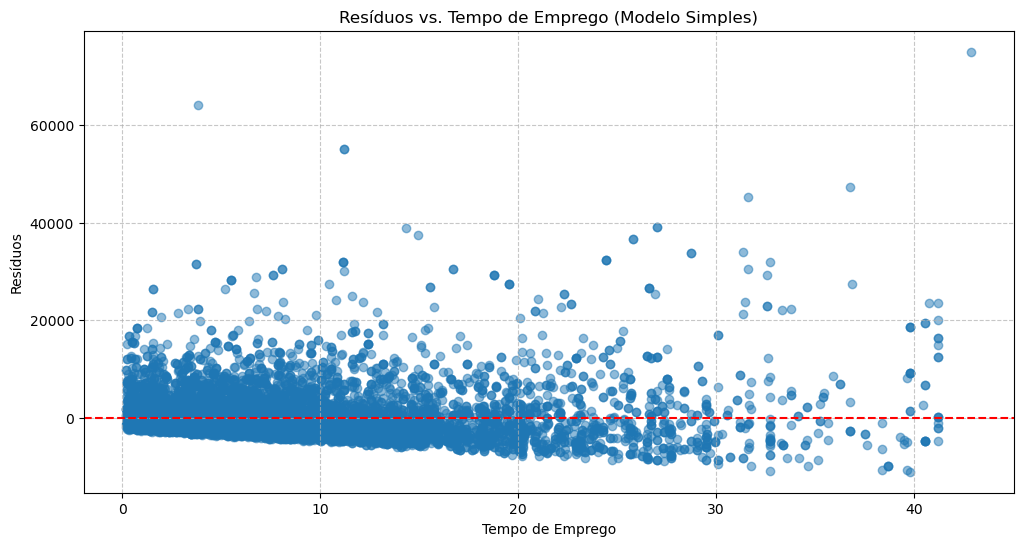


Observações sobre o gráfico de resíduos:
- Há um padrão em funil (heterocedasticidade), indicando que a variância dos resíduos aumenta com o 'tempo_emprego'.
- A linearidade pode não ser a melhor representação, pois os resíduos parecem ter um padrão curvo em relação a 'tempo_emprego'.
- A presença de muitos pontos ao longo do eixo X em 'tempo_emprego' reflete a distribuição dos dados.

--- Como Melhorar esta Regressão Simples? ---
Com base na análise de resíduos (padrão em funil e possível não-linearidade), as principais melhorias seriam:
1.  **Transformação da Variável Resposta (`renda`):** A heterocedasticidade sugere que a variância do erro não é constante. Uma transformação logarítmica em `renda` (`np.log(renda)`) é uma abordagem comum para estabilizar a variância e lidar com distribuições assimétricas (como renda).
2.  **Transformação da Variável Explicativa (`tempo_emprego`):** O gráfico de resíduos também sugere uma relação não-linear. Testar uma transformação logarítmica (`np.

In [22]:
print("\n--- II. Modelo de Regressão Linear Simples: renda ~ tempo_emprego ---")

# Ajustar o modelo
# Usando smf.ols para sintaxe de fórmula mais fácil
model_simples = smf.ols('renda ~ tempo_emprego', data=df_clean).fit()

print(model_simples.summary())

# Análise de Resíduos
print("\n--- Análise de Resíduos do Modelo Simples ---")
df_clean['residuos_simples'] = model_simples.resid
df_clean['renda_predita_simples'] = model_simples.fittedvalues

plt.figure(figsize=(12, 6))
plt.scatter(df_clean['tempo_emprego'], df_clean['residuos_simples'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Tempo de Emprego")
plt.ylabel("Resíduos")
plt.title("Resíduos vs. Tempo de Emprego (Modelo Simples)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nObservações sobre o gráfico de resíduos:")
print("- Há um padrão em funil (heterocedasticidade), indicando que a variância dos resíduos aumenta com o 'tempo_emprego'.")
print("- A linearidade pode não ser a melhor representação, pois os resíduos parecem ter um padrão curvo em relação a 'tempo_emprego'.")
print("- A presença de muitos pontos ao longo do eixo X em 'tempo_emprego' reflete a distribuição dos dados.")


# Como você melhoraria esta regressão?
print("\n--- Como Melhorar esta Regressão Simples? ---")
print("Com base na análise de resíduos (padrão em funil e possível não-linearidade), as principais melhorias seriam:")
print("1.  **Transformação da Variável Resposta (`renda`):** A heterocedasticidade sugere que a variância do erro não é constante. Uma transformação logarítmica em `renda` (`np.log(renda)`) é uma abordagem comum para estabilizar a variância e lidar com distribuições assimétricas (como renda).")
print("2.  **Transformação da Variável Explicativa (`tempo_emprego`):** O gráfico de resíduos também sugere uma relação não-linear. Testar uma transformação logarítmica (`np.log(tempo_emprego)`) ou polinomial (`tempo_emprego**2`) pode ajudar a capturar melhor a relação entre as variáveis.")
print("3.  **Adição de Variáveis Explicativas:** O modelo é muito simples. Incluir outras variáveis relevantes da base de dados (sexo, educação, tipo de renda, etc.) em um modelo de regressão múltipla provavelmente aumentaria significativamente o poder explicativo do modelo (maior R²).")


--- III. Modelo de Regressão Linear Múltipla ---

Variável 'log_renda' criada.

Valores Nulos após limpeza inicial (para variáveis adicionais):
sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
dtype: int64

Número de linhas para o modelo múltiplo após remover NaNs restantes: 12042

--- Ajustando o Modelo Múltiplo Inicial com a fórmula:
log_renda ~ sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda + educacao + estado_civil + tipo_residencia + idade + log_tempo_emprego + qt_pessoas_residencia
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.191


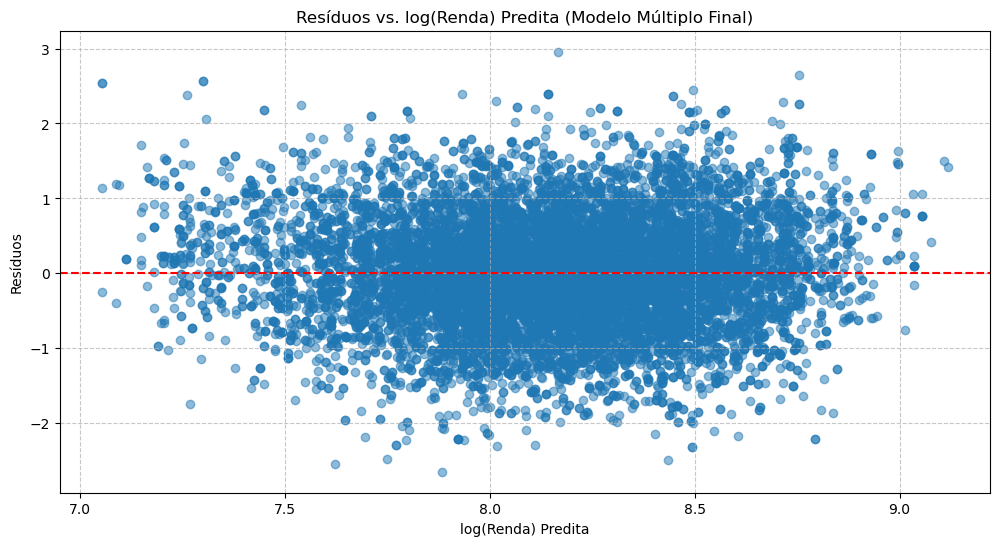


--- Q-Q Plot dos Resíduos do Modelo Múltiplo Final ---


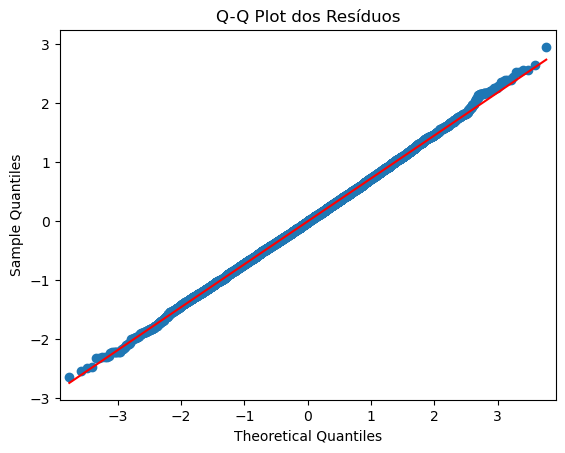


--- Avaliação da Qualidade do Ajuste do Modelo Múltiplo Final ---
R-quadrado Ajustado: 0.1772
O R-quadrado ajustado indica a proporção da variância em `log_renda` que é explicada pelo modelo.
Para a `log_renda`, o R-quadrado tende a ser maior e indicar um bom ajuste.

Observações sobre os gráficos de resíduos:
- **Resíduos vs. Valores Preditos**: Espera-se uma nuvem de pontos aleatória em torno de zero, sem padrões. A transformação logarítmica de `renda` geralmente ajuda a reduzir a heterocedasticidade observada no modelo simples.
- **Q-Q Plot**: Se os resíduos seguem uma distribuição normal, os pontos devem se alinhar aproximadamente ao longo da linha diagonal. Desvios nas caudas indicam não-normalidade.

--- Teste de Breusch-Pagan para Heterocedasticidade ---
Lagrange multiplier statistic    4.125936
p-value                          0.389231
f-value                          1.031409
f p-value                        0.389318
dtype: float64
P-valor >= 0.05: Não há evidências de hetero

In [24]:
print("\n--- III. Modelo de Regressão Linear Múltipla ---")

# 1. Transformar a variável resposta `renda` para `log_renda`
df_clean['log_renda'] = np.log(df_clean['renda'])
print("\nVariável 'log_renda' criada.")

# 2. Preparar as variáveis categóricas
# As variáveis categóricas precisam ser transformadas em variáveis dummy para a regressão.
# Patsy faz isso automaticamente, mas é bom estar ciente.
# Vamos remover quaisquer NaNs restantes em outras colunas que serão usadas no modelo múltiplo.
# Se houver NaNs em 'sexo', 'qtd_filhos', 'tipo_renda', etc., eles precisam ser tratados.
print("\nValores Nulos após limpeza inicial (para variáveis adicionais):")
print(df_clean[['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
                'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
                'tempo_emprego', 'qt_pessoas_residencia']].isnull().sum())

# Vamos remover linhas com NaNs para as variáveis que usaremos no modelo múltiplo
df_multi_model = df_clean.dropna(subset=[
    'sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
    'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
    'qt_pessoas_residencia' # 'tempo_emprego' e 'renda' já foram tratados
]).copy()
print(f"\nNúmero de linhas para o modelo múltiplo após remover NaNs restantes: {len(df_multi_model)}")

# Considerar a transformação logarítmica também para tempo_emprego para o modelo múltiplo.
df_multi_model['log_tempo_emprego'] = np.log(df_multi_model['tempo_emprego'])

# 3. Ajuste o modelo de regressão linear múltipla inicial
# Usaremos 'log_renda' como resposta.
# A fórmula inclui todas as outras variáveis relevantes.
# Patsy cuida de dummyficar as variáveis categóricas.
formula_multi_initial = (
    'log_renda ~ sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + '
    'tipo_renda + educacao + estado_civil + tipo_residencia + idade + '
    'log_tempo_emprego + qt_pessoas_residencia'
)
print(f"\n--- Ajustando o Modelo Múltiplo Inicial com a fórmula:\n{formula_multi_initial}")
model_multi_initial = smf.ols(formula_multi_initial, data=df_multi_model).fit()
print(model_multi_initial.summary())

# 4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros.
print("\n--- Removendo Variáveis Não Significantes e Reajustando o Modelo ---")
print("Analisando os p-valores do modelo inicial para remover variáveis com p > 0.05 (ou um limite que você definir).")
print("Este é um processo iterativo. Vamos remover a variável com o maior p-valor não significante e reajustar.")

# Iterar para remover variáveis não significantes
current_formula = formula_multi_initial
print(f"\nFórmula inicial para remoção iterativa:\n{current_formula}")

# Loop para remoção iterativa
while True:
    model_current = smf.ols(current_formula, data=df_multi_model).fit()
    p_values = model_current.pvalues.drop('Intercept') # Ignorar o intercepto para remoção
    non_significant_vars = p_values[p_values > 0.05]

    if non_significant_vars.empty:
        print("\nTodas as variáveis restantes são significantes (p <= 0.05).")
        break
    else:
        # Remover a variável com o maior p-valor não significante
        var_to_remove = non_significant_vars.idxmax()
        print(f"\nRemovendo: {var_to_remove} (P-valor: {non_significant_vars.max():.4f})")

        # Remover a variável da fórmula
        # Cuidado com categorias dummies: remover 'sexo' remove 'sexo[T.M]' e 'sexo[T.F]' (via Patsy)
        # Patsy automaticamente remove as dummies se a variável categórica principal for removida.
        # Precisamos remover o nome da variável base, não a dummy específica.
        # A forma mais robusta é reconstruir a fórmula excluindo a variável base.

        # Criar uma lista de variáveis na fórmula atual
        variables_in_formula = [term.strip() for term in current_formula.split('~')[1].split('+')]
        # Encontrar qual variável base corresponde à dummy a ser removida
        base_var_to_remove = None
        for var in variables_in_formula:
            if var_to_remove.startswith(var) or var_to_remove == var:
                base_var_to_remove = var
                break
        
        if base_var_to_remove:
            new_variables = [v for v in variables_in_formula if v != base_var_to_remove]
            current_formula = f"log_renda ~ {' + '.join(new_variables)}"
            print(f"Nova fórmula: {current_formula}")
        else:
            # Caso a variável não seja categórica (e não tenha um prefixo), apenas remova-a
            current_formula = current_formula.replace(f' + {var_to_remove}', '')
            current_formula = current_formula.replace(f'{var_to_remove} + ', '') # Para o caso de ser a primeira variável
            current_formula = current_formula.replace(f'~ {var_to_remove}', '~') # Caso seja a única variável explicativa
            print(f"Nova fórmula: {current_formula}")

        # Se a fórmula ficar vazia depois da remoção
        if '~' not in current_formula or current_formula.split('~')[1].strip() == '':
             print("Aviso: Nenhuma variável explicativa restante na fórmula. Interrompendo a remoção.")
             break

# Modelo Final após remoção de não significantes
final_multi_model = smf.ols(current_formula, data=df_multi_model).fit()
print("\n--- Sumário do Modelo Múltiplo Final (Variáveis Significantess) ---")
print(final_multi_model.summary())

# Interpretação dos Parâmetros do Modelo Final
print("\n--- Interpretação dos Parâmetros do Modelo Múltiplo Final ---")
print("Variáveis explicativas (coeficientes):")
for param, coef in final_multi_model.params.drop('Intercept').items():
    p_value = final_multi_model.pvalues[param]
    if 'log_tempo_emprego' in param:
        print(f"- **log_tempo_emprego**: Um aumento de 1% no tempo de emprego está associado a uma mudança de aproximadamente {coef:.2f}% na renda, mantendo outras variáveis constantes.")
    elif 'idade' in param:
        print(f"- **idade**: Um aumento de um ano na idade está associado a uma mudança de aproximadamente {coef:.4f} na log_renda. O efeito percentual na renda é (exp({coef}) - 1) * 100%.")
    elif 'qtd_filhos' in param:
        print(f"- **qtd_filhos**: Um filho adicional está associado a uma mudança de aproximadamente {coef:.4f} na log_renda. O efeito percentual na renda é (exp({coef}) - 1) * 100%.")
    elif 'qt_pessoas_residencia' in param:
        print(f"- **qt_pessoas_residencia**: Uma pessoa adicional na residência está associada a uma mudança de aproximadamente {coef:.4f} na log_renda. O efeito percentual na renda é (exp({coef}) - 1) * 100%.")
    elif 'posse_de_veiculo[T.True]' in param:
        print(f"- **posse_de_veiculo[T.True]**: Possuir veículo está associado a uma mudança de aproximadamente {coef:.4f} na log_renda em comparação com não possuir. O efeito percentual na renda é (exp({coef}) - 1) * 100%.")
    elif 'posse_de_imovel[T.True]' in param:
        print(f"- **posse_de_imovel[T.True]**: Possuir imóvel está associado a uma mudança de aproximadamente {coef:.4f} na log_renda em comparação com não possuir. O efeito percentual na renda é (exp({coef}) - 1) * 100%.")
    else: # Para outras variáveis categóricas ou transformadas
        print(f"- **{param}**: Coeficiente: {coef:.4f}. Interpretação: para uma unidade de mudança na variável (ou mudança da categoria base para esta categoria), a log_renda muda em {coef:.4f}.")
        print(f"  Efeito percentual aproximado na renda: {(np.exp(coef) - 1) * 100:.2f}%")

print("\nInterpretação Geral:")
print("Para variáveis explicativas transformadas com log (como `log_tempo_emprego`), o coeficiente ($\beta$) pode ser interpretado como a elasticidade: um aumento de 1% na variável explicativa está associado a um aumento de $\beta$% na `renda` (pois `log_renda` é a resposta).")
print("Para variáveis binárias ou categóricas, o $exp(\beta) - 1$ dá a variação percentual na `renda` em comparação com a categoria de referência, mantendo as outras variáveis constantes.")
print("Para variáveis numéricas sem log (se houvesse, como `idade`), o $exp(\beta)$ representa a razão de mudança multiplicativa na `renda` para um aumento de uma unidade na variável explicativa.")


# 5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.
print("\n--- Análise de Resíduos do Modelo Múltiplo Final ---")
df_multi_model['residuos_multi'] = final_multi_model.resid
df_multi_model['log_renda_predita_multi'] = final_multi_model.fittedvalues

# Gráfico de resíduos vs. valores preditos (log_renda)
plt.figure(figsize=(12, 6))
plt.scatter(df_multi_model['log_renda_predita_multi'], df_multi_model['residuos_multi'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("log(Renda) Predita")
plt.ylabel("Resíduos")
plt.title("Resíduos vs. log(Renda) Predita (Modelo Múltiplo Final)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfico Q-Q plot para normalidade dos resíduos
print("\n--- Q-Q Plot dos Resíduos do Modelo Múltiplo Final ---")
sm.qqplot(final_multi_model.resid, line='s') # 's' for standardized line
plt.title("Q-Q Plot dos Resíduos")
plt.show()

print("\n--- Avaliação da Qualidade do Ajuste do Modelo Múltiplo Final ---")
print(f"R-quadrado Ajustado: {final_multi_model.rsquared_adj:.4f}")
print("O R-quadrado ajustado indica a proporção da variância em `log_renda` que é explicada pelo modelo.")
print("Para a `log_renda`, o R-quadrado tende a ser maior e indicar um bom ajuste.")
print("\nObservações sobre os gráficos de resíduos:")
print("- **Resíduos vs. Valores Preditos**: Espera-se uma nuvem de pontos aleatória em torno de zero, sem padrões. A transformação logarítmica de `renda` geralmente ajuda a reduzir a heterocedasticidade observada no modelo simples.")
print("- **Q-Q Plot**: Se os resíduos seguem uma distribuição normal, os pontos devem se alinhar aproximadamente ao longo da linha diagonal. Desvios nas caudas indicam não-normalidade.")

# Avaliação da heterocedasticidade com teste (Ex: Breusch-Pagan)
try:
    name = ['Lagrange multiplier statistic', 'p-value',
            'f-value', 'f p-value']
    test = sm.stats.het_breuschpagan(final_multi_model.resid, final_multi_model.model.exog)
    print(f"\n--- Teste de Breusch-Pagan para Heterocedasticidade ---")
    print(pd.Series(test, index=name))
    if test[1] < 0.05:
        print("P-valor < 0.05: Há evidências de heterocedasticidade. A variância dos resíduos não é constante.")
    else:
        print("P-valor >= 0.05: Não há evidências de heterocedasticidade. A variância dos resíduos é constante (homocedasticidade).")
except Exception as e:
    print(f"\nNão foi possível rodar o teste de Breusch-Pagan: {e}")
    print("Isso pode acontecer se o número de variáveis explicativas for muito alto ou se houver multicolinearidade perfeita.")

print("\n--- Conclusão da Qualidade do Ajuste ---")
print("A qualidade do ajuste é avaliada pelo R-quadrado ajustado (poder explicativo), pela análise dos resíduos (homocedasticidade e normalidade) e pela significância estatística das variáveis.")
print("Um R-quadrado ajustado mais alto é melhor. Padrões aleatórios nos resíduos e pontos alinhados no Q-Q plot indicam um bom ajuste.")
print("Se houver heterocedasticidade, técnicas como 'robust standard errors' (erros padrão robustos) ou GLM podem ser consideradas.")